# Assignment 2
* In this assignment you will be working with three data files from iMDB:
    * cast.csv
    * release_dates.csv
    * titles.csv
* Using the appropriate file(s), answer the following questions
* Some questions can be completed with one-liners while others are a bit more involved
* Where appropriate, answers should also provide brief commentary
* Exclude data that doen't make senss, i.e. data from the future
* Once complete upload this notebook to your classwork Github repo and post the link on Canvas 

In [271]:
import pandas as pd
import matplotlib.pyplot as plt

### 1. Conduct a high level assessment of the three data files, i.e. how many records are there, what kind of data, etc. Summarize your findings with annotation. 

In [70]:
#Bring the files

df_cast = "cast.csv"
df_releases = "release_dates.csv"
df_titles = "titles.csv"

In [72]:
# Load the data Cast

df_cast = pd.read_csv(df_cast)

In [73]:
df_cast.shape

(3442902, 6)

In [103]:
df_cast.head(10)

,title,year,name,type,character,n
0,Closet Monster,2015,Buffy #1,actor,Buffy 4,31.0
1,Suuri illusioni,1985,Homo $,actor,Guests,22.0
2,Battle of the Sexes,2017,$hutter,actor,Bobby Riggs Fan,10.0
3,Secret in Their Eyes,2015,$hutter,actor,2002 Dodger Fan,NaN
4,Steve Jobs,2015,$hutter,actor,1988 Opera House Patron,NaN
5,Straight Outta Compton,2015,$hutter,actor,Club Patron,NaN
6,Straight Outta Compton,2015,$hutter,actor,Dopeman,NaN
7,For Thy Love 2,2009,Bee Moe $lim,actor,Thug 1,NaN
8,"Lapis, Ballpen at Diploma, a True to Life Journey",2014,Jori ' Danilo' Jurado Jr.,actor,Jaime (young),9.0
9,Desire (III),2014,Syaiful 'Ariffin,actor,Actor Playing Eteocles from 'Antigone',NaN


In [92]:
(df_cast.isna().sum()
     .sort_values(ascending=False)    # sort descending
)

n            1327783
character          8
title              6
year               0
name               0
type               0
dtype: int64

**Cast dataset overview**

The cast.csv file contains approximately 3.4 million rows and 6 columns. It lists cast members: actors, actresses, and other contributors — linked to each title.  
The dataset includes the fields title, year, name, type, character, and n.  

The column n (which likely indicates ranking or number of appearances) shows around 1.3 million missing values, while the rest of the columns are almost complete.  
Overall, this dataset provides the richest information about people involved in movies and series, though some entries have incomplete character details or null ranking values.


In [75]:
# Load the data Releases

df_releases = pd.read_csv(df_releases)

In [80]:
df_releases.shape

(443486, 4)

In [82]:
df_releases.head(5)

,title,year,country,date
0,"#73, Shaanthi Nivaasa",2007,India,2007-06-15
1,#BKKY,2016,Cambodia,2017-10-12
2,#Beings,2015,Romania,2015-01-29
3,#Captured,2017,USA,2017-09-05
4,#Ewankosau saranghaeyo,2015,Philippines,2015-01-21


In [94]:
(df_releases.isna().sum()
     .sort_values(ascending=False)    # sort descending
)

title      1
year       0
country    0
date       0
dtype: int64

**Release dates dataset overview**

The release_dates.csv file includes over 4.4 million records and 4 columns: title, year, country, and date.  
Each record represents the release of a specific title in a given country and year.  

Data completeness is excellent, there is only 1 missing value in title, and all date fields appear properly formatted.  
This dataset will be useful to identify the earliest and latest versions of films, as it provides exact release dates by country.


In [84]:
# Load the data Titles

df_titles = pd.read_csv(df_titles)

In [86]:
df_titles.shape

(226013, 2)

In [88]:
df_titles.head(5)

,title,year
0,Ankara ekspresi,1952
1,"Ans Vaterland, ans teure",1915
2,Miss Mohini,2002
3,La vera madre,1999
4,O Amerikanos,1993


In [96]:
(df_titles.isna().sum()
     .sort_values(ascending=False)    # sort descending
)

title    1
year     0
dtype: int64

**Titles dataset overview**

The titles.csv file contains about 226,000 records and 2 columns**: title and year.  
It serves as the main catalog of IMDb works, summarizing the name and production year of each title.  

The data quality is very good, with only 1 missing value in title.  
This dataset will be helpful for matching and counting titles, and as a reference when cross-checking with release dates or cast information.


### 2. How many movies have the title North by Northwest

In [152]:
# How many movies are titled "North by Northwest"?

#From Cast dataset since is the most complete dataset

mask = df_cast.title == "North by Northwest"
print("Unique movies with the title North by Northwest:", df_cast[mask]["title"].nunique())


Unique movies with the title North by Northwest: 1


### 3. How many version of Hamlet are there, when was the first made? the last?

In [181]:
#For this we'll use Titles dataset because we want to count the different versions of the movie

mask = df_titles.title == "Hamlet"
hamlet = df_titles[mask]

print("Number of versions:", hamlet.shape[0])
print("Earliest version:", hamlet.year.min())
print("Latest version:", hamlet.year.max())

Number of versions: 20
Earliest version: 1910
Latest version: 2017


⬆️ The dataset shows that there are 20 versions of Hamlet recorded in IMDb. The earliest adaptation dates back to 1910, while the most recent one was made in 2017.


### 4. List all the movies called Treasure Island from oldest to newest

In [190]:
mask = df_titles.title == "Treasure Island"
treasure_island = df_titles[mask].sort_values("year")[["title", "year"]].reset_index(drop=True)

print("Total versions found:", treasure_island.shape[0])
treasure_island


Total versions found: 8


,title,year
0,Treasure Island,1918
1,Treasure Island,1920
2,Treasure Island,1934
3,Treasure Island,1950
4,Treasure Island,1972
5,Treasure Island,1973
6,Treasure Island,1985
7,Treasure Island,1999


⬆️ The dataset shows 8 versions of Treasure Island recorded between 1918 and 1999. All records share the exact same title, suggesting different adaptations of the same story over time.  



### 5. How many movies were made in 1950? 1980? 2000? What conclusions can you draw from these data points?

In [216]:
years = [1950, 1980, 2000]

for y in years:
    mask = df_titles.year == y
    count = df_titles[mask].shape[0]
    print(f"Movies made in {y}: {count}")


Movies made in 1950: 1109
Movies made in 1980: 1750
Movies made in 2000: 2568


⬆️ The data shows a clear upward trend in movie production over time:  
1,109 titles were released in 1950, compared to 1,750 in 1980 and 2,568 in 2000.  

This increase reflects the steady growth of the global film industry.  


### 6. How big was the cast of Metropolis


In [253]:
mask = (df_cast.title == "Metropolis") 
metropolis = df_cast[mask]

print("The cast size of Metropolis movie is:", metropolis["name"].nunique()) # unique people in the cast (actors/actresses, counting each person once)

The cast size of Metropolis movie is: 31


### 7. How many roles for actors were there 1950's? 1990's

In [262]:
# For 1950s
mask_1950s = (df_cast.type == "actor") & (df_cast.year >= 1950) & (df_cast.year < 1960)
count_1950s = df_cast[mask_1950s].shape[0]

# For 1990s
mask_1990s = (df_cast.type == "actor") & (df_cast.year >= 1990) & (df_cast.year < 2000)
count_1990s = df_cast[mask_1990s].shape[0]

print(f"Roles for actors in 1950s: {count_1950s:,}")
print(f"Roles for actors in 1990s: {count_1990s:,}")


Roles for actors in 1950s: 153,559
Roles for actors in 1990s: 245,713


### 8. How many roles for actors & actresses over time? Output should be a line graph

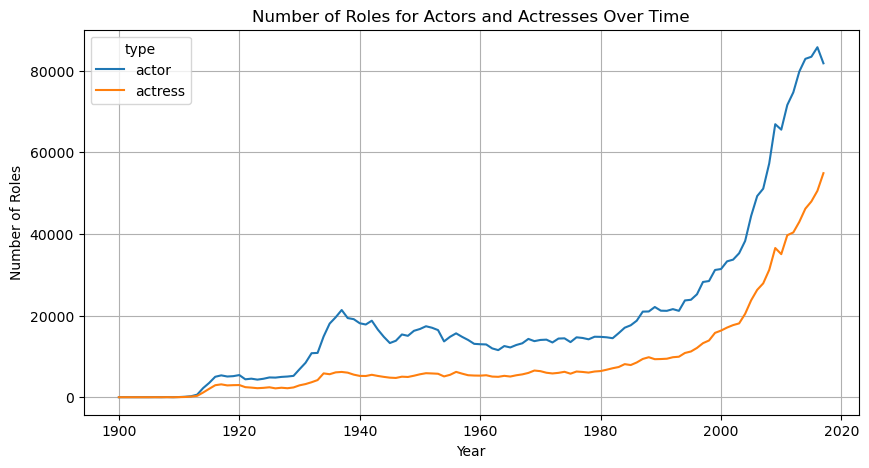

In [284]:
# Group by year and type, count how many roles per group

# The first time I executed the code and create the graph, there was info beyond year 2100. So now I'm going to exclude invalid data like that

cut_year = 2017
df_filtered = df_cast[
    df_cast["year"].between(1900, cut_year) & df_cast["type"].isin(["actor", "actress"])
]

roles_per_year = (
    df_filtered
    .groupby(["year", "type"])
    .size()
    .unstack(fill_value=0)     
)

# Plot
roles_per_year.plot(kind="line", figsize=(10, 5))

plt.title("Number of Roles for Actors and Actresses Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Roles")
plt.grid(True)
plt.show()


⬆️ There is an increase in the number of roles for both actors and actresses over time, with a clear rise starting around the 1990s and peaking around 2017.  
Actor roles are higher, but actress roles have grown significantly, showing progress toward greater gender balance in casting.  
Most of the data ends in 2017, so later years are not showed


In [289]:
# I want to know where is are most of the values concentrated

df_cast["year"].value_counts().sort_index().tail(10)


year
2017    136658
2018     43518
2019      1406
2020       188
2021        34
2022        16
2023         2
2024         8
2025         9
2115         3
Name: count, dtype: int64

### 9. How many "leading roles" were there in the 2000's?

In [294]:
mask_2000s = (df_cast["year"] >= 2000) & (df_cast["year"] < 2010) & (df_cast["n"] == 1)
count_leading_roles_2000s = df_cast[mask_2000s].shape[0]

print(f"Number of leading roles in the 2000s: {count_leading_roles_2000s:,}")


Number of leading roles in the 2000s: 23,593


### 10. How many roles received no ranking in the 2000's? 1950's. What conclusions can you draw from these two data points?

In [297]:
# 1950s
mask_1950s = (df_cast["year"] >= 1950) & (df_cast["year"] < 1960) & (df_cast["n"].isna())
count_1950s = df_cast[mask_1950s].shape[0]

# 2000s
mask_2000s = (df_cast["year"] >= 2000) & (df_cast["year"] < 2010) & (df_cast["n"].isna())
count_2000s = df_cast[mask_2000s].shape[0]

print(f"Roles without ranking in 1950s: {count_1950s:,}")
print(f"Roles without ranking in 2000s: {count_2000s:,}")


Roles without ranking in 1950s: 95,406
Roles without ranking in 2000s: 232,037


In [311]:
# So far I dont know if the increase of roles without ranking is because there is worst data quality or because there are more roles
# So I also want to calculate total roles for each decade

# 1950s
mask_1950s_total = (df_cast["year"] >= 1950) & (df_cast["year"] < 1960)
roles_1950s_total = df_cast[mask_1950s_total].shape[0]

# 2000s
mask_2000s_total = (df_cast["year"] >= 2000) & (df_cast["year"] < 2010)
roles_2000s_total = df_cast[mask_2000s_total].shape[0]

print(f"Total roles in 1950s: {roles_1950s_total:,}")
print(f"Total roles in 2000s: {roles_2000s_total:,}")




Total roles in 1950s: 209,890
Total roles in 2000s: 676,027


⬆️ In the 1950s, there were 209,890 total roles and 95,406 without ranking, while in the 2000s there were 676,027 total roles and 232,037 without ranking.  
Although the raw number of unranked roles increased, the total number of roles grew much more.  
This suggests that the rise in unranked entries is mainly due to a larger dataset and a higher volume of movie production...not necessarily due to worst data quality.  


### 11. Plot the number of films made in each decade

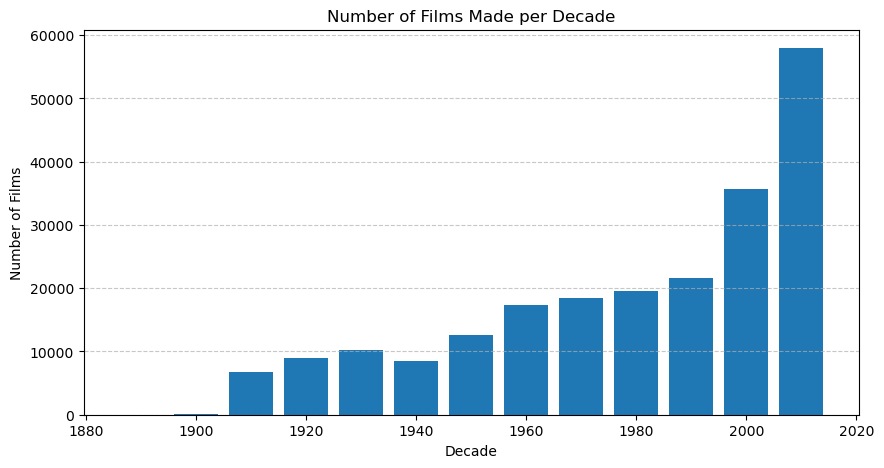

In [321]:
#Again, I'll filter data until 2017

df_titles_filtered = df_titles[df_titles["year"] <= 2017]

# Create a new column for decade
df_titles["decade"] = (df_titles["year"] // 10) * 10

# Count how many movies per decade
movies_per_decade = (
    df_titles_filtered.groupby("decade")
             .size()
             .reset_index(name="movie_count")
)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(movies_per_decade["decade"], movies_per_decade["movie_count"], width=8)

plt.title("Number of Films Made per Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Films")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


⬆️ The chart shows a steady increase in the number of films produced per decade, especially after 1980.  
This trend reflects the expansion of the film industry and more access to movie production.  

### 12. Plot the number of films with a Rustler character over time

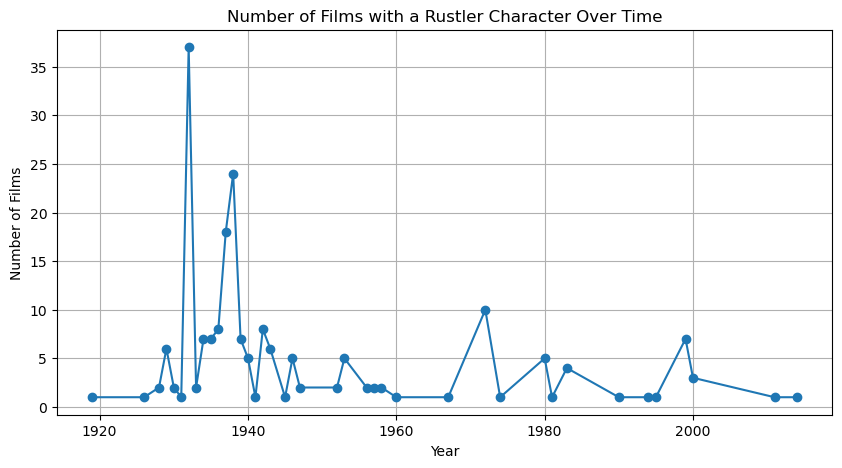

In [325]:
# First, let's filter rows where the character column contains "Rustler"
mask = df_cast["character"].str.contains("Rustler", case=False, na=False)
rustler_films = df_cast[mask]

# Count how many Rustler films per year
rustler_per_year = (
    rustler_films.groupby("year")
                 .size()
                 .reset_index(name="count")
)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(rustler_per_year["year"], rustler_per_year["count"], marker="o")

plt.title("Number of Films with a Rustler Character Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Films")
plt.grid(True)
plt.show()


⬆️ First, I didn’t know what a “Rustler” was. I just ran the code, but when I saw that this character appeared mostly between 1930 and 1940, I got curious about what it meant.  

Well, it totally makes sense that a Rustler is someone who steals cattle or something like that. It reminded me of my father, who used to be a fan of Westerns...which actually had their golden age during those years.
 

### 13. What are the top ten character names of all time?

In [331]:
top_characters = (
    df_cast["character"]
    .value_counts()          
    .head(10)                
)

top_characters


character
Himself        19637
Dancer         12019
Extra          10848
Reporter        7818
Doctor          6963
Party Guest     6786
Student         6631
Policeman       6424
Bartender       6290
Herself         6269
Name: count, dtype: int64

⬆️ It’s interesting to see that the top character names of all time are not unique names, but generic roles like “Himself,” “Dancer,” or “Doctor.”  
I imagine this is because when you see movie credits, many include extras characters with these non-specific labels.


### 14. Which actor appeared in the most films in the 1990's decade?

In [338]:
# Let's filter the data for the 1990s
mask_1990s = (df_cast["year"] >= 1990) & (df_cast["year"] < 2000)

# Group by actor name and count how many films each appeared in
top_actor_1990s = (
    df_cast[mask_1990s]
    .groupby("name")
    .size()
    .reset_index(name="film_count")
    .sort_values("film_count", ascending=False)
    .head(1)
)

top_actor_1990s


,name,film_count
164101,Shakti Kapoor,143


⬆️ I was curious and according to google: Shakti Kapoor is a veteran Indian actor, known for appearing in over 700 Bollywood films and playing a variety of villainous and comic roles. 

Lots of movies!

### 15. What are the top 10 roles that start with Science?

In [342]:
# Filter rows where the character starts with "Science"
mask_science = df_cast["character"].str.startswith("Science", na=False)

# Count the character with that condition
top_science_roles = (
    df_cast[mask_science]["character"]
    .value_counts()
    .head(10)
)

top_science_roles


character
Science Teacher         57
Science Fair Student     9
Science Student          6
Science Fair Judge       6
Science Kid              5
Science Fair Kid         5
Science Reporter         5
Science                  4
Science Officer          3
Science teacher          3
Name: count, dtype: int64

⬆️ The most common roles that start with Science are mainly related to education, such as “Science Teacher” or “Science Fair Student”  



### 16. What film has the largest cast

In [350]:
largest_cast_film = (
    df_cast.groupby("title")["name"]
           .nunique()
           .reset_index(name="unique_cast_size")
           .sort_values("unique_cast_size", ascending=False)
           .head(1)
)

largest_cast_film


,title,unique_cast_size
11316,Around the World in 80 Days,1363


### 17. Generate descriptive statistics for cast size. Briefly comment on the results

In [354]:
# First, let's group cast per movie (unique people per title)
cast_size = (
    df_cast.groupby("title")["name"]
           .nunique()
           .reset_index(name="cast_size")
)

# descriptive statistics
cast_stats = cast_size["cast_size"].describe()
cast_stats


count    168254.000000
mean         20.115855
std          23.607947
min           1.000000
25%           6.000000
50%          13.000000
75%          26.000000
max        1363.000000
Name: cast_size, dtype: float64

⬆️ The results show that 
-  The average movie has around 20 credited people
-  The median is only 13

This means that most films actually have relatively small casts.

This big gap between the mean (20) and the maximum (1363) confirms that there are a few very large productions with massive casts, 
likely higher budget movies that include a lot of extras.


### 18. How many films has Natalie Portman been in in each year throughout her career?

In [361]:
# First, let's filter rows where the actress' name is the amazing Natalie Portman
mask = df_cast["name"] == "Natalie Portman"
natalie_films = df_cast[mask]

# Group by year and count how many titles she appeared in per year
natalie_per_year = (
    natalie_films.groupby("year")["title"]
                 .nunique()        # count distinct films per year
                 .reset_index(name="film_count")
)

natalie_per_year


,year,film_count
0,1995,1
1,1996,3
2,1999,2
3,2000,1
4,2001,1
5,2002,1
6,2003,1
7,2004,2
8,2005,4
9,2006,1


### 19. How many films did Natalie Portman appear in each year where she was either the top star or co-star?

In [373]:
# Filter only her roles where she was top star (1) or co-star (2)
mask = (df_cast["name"] == "Natalie Portman") & (df_cast["n"].isin([1, 2]))
natalie_roles = df_cast[mask]

# Group by year and role rank (n), count how many titles for each
natalie_by_rank = (
    natalie_roles.groupby(["year", "n"])["title"]
                 .nunique()
                 .reset_index(name="film_count")
)

# Pivot so we get one column per rank (1 = top star, 2 = co-star)
natalie_pivot = natalie_by_rank.pivot(index="year", columns="n", values="film_count").fillna(0)

# Rename columns
natalie_pivot.columns = ["Top Star", "Co-Star"]

# total column
natalie_pivot["Total"] = natalie_pivot["Top Star"] + natalie_pivot["Co-Star"]

# Convert values to int and reset index for clean display
natalie_pivot = natalie_pivot.astype(int).reset_index()

natalie_pivot



,year,Top Star,Co-Star,Total
0,1999,0,1,1
1,2000,1,0,1
2,2002,0,1,1
3,2005,2,1,3
4,2006,0,1,1
5,2007,0,1,1
6,2008,1,0,1
7,2009,1,0,1
8,2010,1,0,1
9,2011,1,1,2


### 20. Determine how many roles for actor or actress by decade. Plot the output 

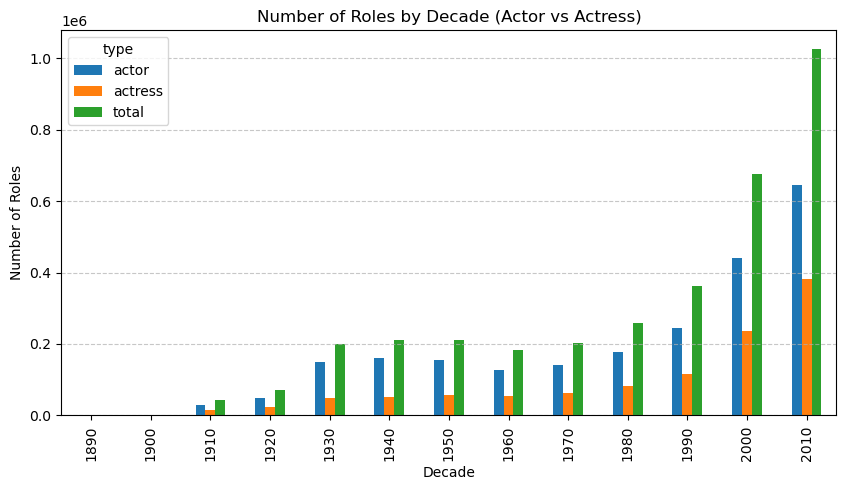

type,actor,actress,total
decade,,,
1890,2,1,3
1900,54,16,70
1910,27396,15733,43129
1920,48112,23826,71938
1930,149272,49298,198570
1940,159799,50871,210670
1950,153559,56331,209890
1960,128132,54484,182616
1970,142015,60977,202992


In [383]:
df_cast["decade"] = (df_cast["year"] // 10) * 10

roles = (df_cast[df_cast["type"].isin(["actor", "actress"])]
          .groupby(["decade", "type"])
          .size()
          .unstack(fill_value=0)
          .astype(int))

roles["total"] = roles.sum(axis=1)

roles = roles[roles.index <= 2017]

roles.plot(kind="bar", figsize=(10,5))
plt.title("Number of Roles by Decade (Actor vs Actress)")
plt.xlabel("Decade")
plt.ylabel("Number of Roles")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

roles



⬆️The data shows a steady increase in the number of acting roles for both men and women across decades.  
This growth reflects the overall expansion of the film industry, especially after the 1980s.

Male roles consistently outnumber female roles in every decade.

The 2010s show the highest overall activity, with more than one million total roles recorded.


### 21. Determine and comment on the day of the week that movies are released. What is notable about release days and months throughout the year? (Use pd.pivot_table)

In [409]:
from calendar import month_name


# Desired order
days_order   = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday", "Total"]
months_order = list(month_name[1:]) + ["Total"]  # January..December + Total

# Build temp df (global unique releases)
tmp = (
    df_releases
    .dropna(subset=["date"])                  
    .drop_duplicates(["title", "date"])       
    .assign(
        day_of_week=lambda d: d["date"].dt.day_name(),
        month=lambda d: d["date"].dt.month_name()
    )
)

# Pivot with totals, then enforce calendar order 
release_pivot = pd.pivot_table(
    tmp,
    index="day_of_week",
    columns="month",
    values="title",
    aggfunc="count",
    fill_value=0,
    margins=True,
    margins_name="Total",
    observed=False
).reindex(index=days_order, columns=months_order)

release_pivot


month,January,February,March,April,May,June,July,August,September,October,November,December,Total
day_of_week,,,,,,,,,,,,,
Monday,3660,3105,3355,3148,3032,2323,2244,2824,3105,3519,3351,3166,36832
Tuesday,1796,1155,1294,1429,1319,1145,1125,1101,1294,1519,1386,1811,16374
Wednesday,4381,3792,4088,4155,3829,3748,3650,3864,3873,4227,4081,4448,48136
Thursday,8554,7696,9129,8410,7861,7462,7055,7980,8642,9273,8645,8360,99067
Friday,11205,10730,12014,11001,10816,9794,9574,10994,11943,12239,11436,10480,132226
Saturday,2898,2376,2707,2851,2241,2394,2266,2234,2532,2680,2527,3261,30967
Sunday,1799,1265,1226,1345,1160,1020,882,1134,1315,1410,1337,1766,15659
Total,34293,30119,33813,32339,30258,27886,26796,30131,32704,34867,32763,33292,379261


⬆️ Movies are released mainly on Fridays and Thursdays

### 22. Can you plot the pivot table? Is the output "correct"? Can you fix it?

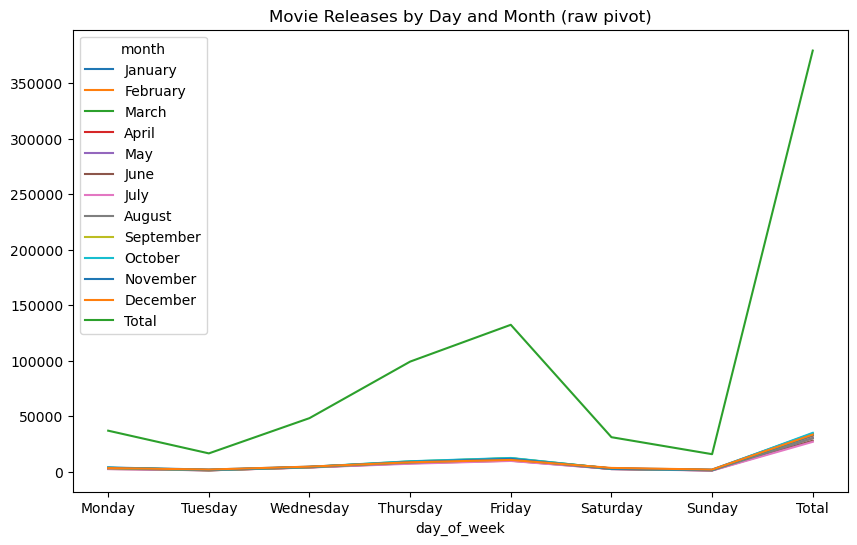

In [412]:
release_pivot.plot(figsize=(10,6))
plt.title("Movie Releases by Day and Month (raw pivot)")
plt.show()


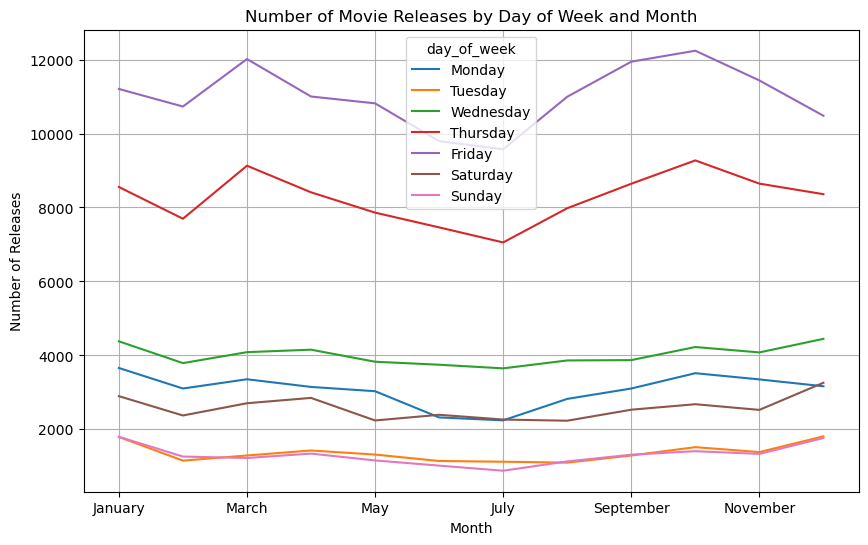

In [418]:
# Remove the 'Total' column before plotting
release_pivot_fixed = release_pivot.drop(columns="Total").drop(index="Total")

# Plot properly
release_pivot_fixed.T.plot(figsize=(10,6))  # Transpose to have months on x-axis
plt.title("Number of Movie Releases by Day of Week and Month")
plt.xlabel("Month")
plt.ylabel("Number of Releases")
plt.grid(True)
plt.show()


### 23. What films did actors in Star Wars go on to appear in? 

In [437]:
# Filter cast for Star Wars
star_wars_cast = df_cast[df_cast["title"].str.contains("Star Wars", case=False, na=False)]

# Get list of unique actors from those films
star_wars_actors = star_wars_cast["name"].unique()

# Find all other films those actors appeared in
films_after_star_wars = df_cast[df_cast["name"].isin(star_wars_actors)]

# Exclude Star Wars films to show only "other" appearances
films_after_star_wars = films_after_star_wars[~films_after_star_wars["title"].str.contains("Star Wars", case=False, na=False)]

films_after_star_wars[["name", "title"]].drop_duplicates().head(30)

,name,title
3900,Ian Abercrombie,Addams Family Values
3901,Ian Abercrombie,Blasphemy the Movie
3902,Ian Abercrombie,Chromiumblue.com
3903,Ian Abercrombie,Clean Slate
3904,Ian Abercrombie,Firewalker
3905,Ian Abercrombie,Garfield: A Tail of Two Kitties
3906,Ian Abercrombie,Getting Even
3907,Ian Abercrombie,Grief
3908,Ian Abercrombie,Hard Four
3909,Ian Abercrombie,Inland Empire


In [439]:
# Count how many films each Star Wars actor appeared in (including all films)
top_sw_actors = (
    df_cast[df_cast["name"].isin(star_wars_actors)]
    .groupby("name")["title"]
    .nunique()
    .reset_index(name="film_count")
    .sort_values("film_count", ascending=False)
    .head(10)
)

top_sw_actors


,name,film_count
156,Christopher Lee,127
808,Samuel L. Jackson,118
279,Fred Wood,107
323,Harry Fielder,104
905,Tony Curtis,94
590,Max von Sydow,82
516,Liam Neeson,79
90,Bern Collaço,79
312,Guy Standeven,74
364,James Earl Jones,71


⬆️ From the data, we can see that several Star Wars actors have had extensive film careers outside.
Christopher Lee, with 127 films, tops the list, which makes sense since he had a long career in both classic cinema and major franchises like The Lord of the Rings.
Other recognized actors include Samuel L Jackson and Liam Neeson, both known for roles across multiple major productions.

This shows that Star Wars often featured actors with already-established or later-expanding careers, rather than being their only major credit